# Cross-Population Transferability of a Dizygotic-Twinning Polygenic Predisposition Score in African Populations
### A hybrid (literature + machine-learning) score, Bayesian-optimised, with the Yoruba (YRI) at the centre

**Pipeline**
1. Pull **individual genotypes** from the open **1000 Genomes Project** at known maternal DZ-twinning loci (incl. Yoruba-in-Ibadan, Nigeria = YRI).
2. Build a classical **literature-weighted PRS**.
3. Test **cross-population transferability** (allele-frequency divergence, Fst).
4. Build a **NOVEL hybrid score** = blend of literature PRS + ML component, with blend & ML hyper-parameters **Bayesian-optimised (Optuna)** under **leave-one-population-out CV** against known population twinning rates.
5. Explain with **SHAP**; **save a model bundle** for the Flask app.

**Honesty box — read before running**
- No public dataset links individual *African* genotypes to twin births. This is a **predisposition + transferability** study, **not** a validated clinical predictor. Say so in the paper; that honesty is what gets it accepted.
- The optimisation target is the **known population twinning rate** (Yoruba ~45/1000): an **ecological proxy** — a stated limitation.
- Effect sizes come from published GWAS (FSHB +18%/allele, SMAD3 +9%/allele). Add other loci only with GWAS-Catalog-verified numbers (helper provided). **Never invent effect sizes.**


## 0 · Setup

In [102]:
# Colab/fresh machine: uncomment to install
# !pip -q install pysam scikit-learn optuna shap pandas numpy scipy matplotlib seaborn joblib requests
import warnings, json; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, requests
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import optuna, shap, joblib
import matplotlib.pyplot as plt, seaborn as sns
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_context("talk"); sns.set_style("whitegrid")
RNG = np.random.default_rng(42)
print("Ready.")

Ready.


## 1 · Twinning scoring table (literature-sourced)
Two robustly replicated maternal DZ-twinning variants pre-filled (per-allele OR from the Iceland replication). `beta = ln(OR)`. Add GWAS-Catalog-verified loci (GNRH1, FSHR, ZFPM1, IPO8) with the helper in 1b; the pipeline auto-scales to any number of SNPs.

In [103]:
SCORE_TABLE = pd.DataFrame([
    # All effect alleles VERIFIED from Mbarek 2024 Table 2 (the listed allele has beta<0 = twinning-DECREASING,
    # so the twinning-INCREASING / risk allele is the other one). OR are per-allele, risk-increasing direction.
    {"rsid":"rs11031006","gene":"FSHB", "effect_allele":"G","OR":1.18},  # 2016 Iceland (+18%/allele G)
    {"rsid":"rs17293443","gene":"SMAD3","effect_allele":"C","OR":1.09},  # Table 2 t/c, beta<0 -> risk = C
    {"rsid":"rs4871939", "gene":"GNRH1","effect_allele":"G","OR":1.08},  # Table 2 a/g, beta<0 -> risk = G (common, freq 0.75)
    {"rsid":"rs4584807", "gene":"ZFPM1","effect_allele":"C","OR":1.07},  # Table 2 t/c, beta<0 -> risk = C
])
SCORE_TABLE["beta"] = np.log(SCORE_TABLE["OR"])
SNPS = SCORE_TABLE["rsid"].tolist()
print(len(SNPS), "loci with effect alleles verified from the source table:")
SCORE_TABLE

4 loci with effect alleles verified from the source table:


,rsid,gene,effect_allele,OR,beta
0,rs11031006,FSHB,G,1.18,0.165514
1,rs17293443,SMAD3,C,1.09,0.086178
2,rs4871939,GNRH1,G,1.08,0.076961
3,rs4584807,ZFPM1,C,1.07,0.067659


### 1b · Effect alleles are set from the paper, not auto-resolved
All four risk alleles are taken directly from **Mbarek 2024, Table 2** (the tabulated allele has a negative beta = twinning-decreasing, so the risk allele is the other one): FSHB=G, SMAD3=C, GNRH1=G (common), ZFPM1=C. The GWAS-Catalog resolver is skipped because it returned wrong-trait associations for GNRH1 and ZFPM1.

In [104]:
# NOTE: the GWAS-Catalog auto-resolver is intentionally NOT used.
# It returned wrong-trait associations for GNRH1 and ZFPM1, so all four effect alleles
# are set directly from Mbarek 2024 Table 2 in the cell above. Nothing to run here.
print("Effect alleles fixed from the source table; resolver skipped.")
print(SCORE_TABLE[["rsid","gene","effect_allele","OR"]].to_string(index=False))

Effect alleles fixed from the source table; resolver skipped.
      rsid  gene effect_allele   OR
rs11031006  FSHB             G 1.18
rs17293443 SMAD3             C 1.09
 rs4871939 GNRH1             G 1.08
 rs4584807 ZFPM1             C 1.07


## 2 · Data source switch
`USE_SYNTHETIC=False` → real 1000 Genomes (needs internet; use for real results).
`USE_SYNTHETIC=True` → structured fake data for an offline dry-run (never publish).
Real-download failure auto-falls back to synthetic with a loud warning.

In [107]:
USE_SYNTHETIC = False   # set False for the real study

### 2a · Real 1000 Genomes loader
Resolve each rsID to its GRCh37 position (Ensembl REST), then `tabix`-fetch only that one position from the public phase-3 VCF (a few KB, not TB). Effect-allele dosage matched to VCF REF/ALT with strand-flip handling.

In [108]:

KG="http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502"
PANEL=f"{KG}/integrated_call_samples_v3.20130502.ALL.panel"
ENS="https://grch37.rest.ensembl.org"; COMP={"A":"T","T":"A","C":"G","G":"C"}

def resolve_grch37(rsid):
    r=requests.get(f"{ENS}/variation/human/{rsid}",headers={"Content-Type":"application/json"},timeout=30)
    r.raise_for_status()
    for m in r.json().get("mappings",[]):
        c=str(m["seq_region_name"])
        if c in [str(i) for i in range(1,23)]: return c,int(m["start"])
    raise ValueError(f"no autosomal GRCh37 mapping for {rsid}")

def load_1000g():
    import pysam
    panel=pd.read_csv(PANEL,sep="\t").dropna(axis=1,how="all")
    panel=panel.rename(columns={panel.columns[0]:"sample"})[["sample","pop","super_pop"]].set_index("sample")
    cols={}; samples_ref=None
    for _,row in SCORE_TABLE.iterrows():
        rsid,ea=row["rsid"],row["effect_allele"]
        chrom,pos=resolve_grch37(rsid)
        url=f"{KG}/ALL.chr{chrom}.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"
        tb=pysam.TabixFile(url); hdr=list(tb.header); samples=hdr[-1].split("\t")[9:]
        if samples_ref is None: samples_ref=samples
        rec=None
        for line in tb.fetch(chrom,pos-1,pos):
            f=line.split("\t")
            if f[2]==rsid or int(f[1])==pos: rec=f; break
        if rec is None: print(f"  ! {rsid} not in VCF; skipped"); continue
        ref,alt=rec[3],rec[4].split(",")[0]
        if   ea==alt: eff_alt=True
        elif ea==ref: eff_alt=False
        elif COMP.get(ea)==alt: eff_alt=True   # strand flip
        elif COMP.get(ea)==ref: eff_alt=False
        else: print(f"  ! {rsid}: effect {ea} not in VCF {ref}/{alt}; skipped"); continue
        dos=[]
        for g in rec[9:]:
            gt=g.split(":")[0].replace("|","/").split("/"); a=sum(1 for x in gt if x=="1")
            dos.append(a if eff_alt else 2-a)
        cols[rsid]=dos
        print(f"  {rsid} ({row['gene']}) chr{chrom}:{pos} REF/ALT={ref}/{alt} effect={ea} OK")
    G=pd.DataFrame(cols,index=samples_ref)
    meta=panel.loc[panel.index.intersection(G.index)].copy(); G=G.loc[meta.index]
    return G,meta


### 2b · Synthetic fallback (offline dry-run only)

In [109]:

SPP={"AFR":["YRI","ESN","GWD","LWK","MSL","ACB","ASW"],"EUR":["CEU","GBR","FIN","IBS","TSI"],
     "EAS":["CHB","JPT","CHS","CDX","KHV"],"SAS":["GIH","PJL","BEB","STU","ITU"],"AMR":["MXL","PUR","CLM","PEL"]}
P2S={p:s for s,ps in SPP.items() for p in ps}
def make_synth(n=80):
    rows=[]
    for s in SNPS:
        b=RNG.uniform(.15,.45); k=RNG.uniform(.10,.30)
        for p in P2S:
            f=b+(k if P2S[p]=="AFR" else 0)+RNG.normal(0,.02); rows.append((s,p,float(np.clip(f,.01,.99))))
    fdf=pd.DataFrame(rows,columns=["rsid","pop","f"]); idx=[]; gen={s:[] for s in SNPS}; sp=[]
    for p in P2S:
        for i in range(n):
            idx.append(f"{p}_{i:03d}"); sp.append(P2S[p])
            for s in SNPS:
                f=fdf[(fdf.rsid==s)&(fdf["pop"]==p)]["f"].iloc[0]; gen[s].append(RNG.binomial(2,f))
    G=pd.DataFrame(gen,index=idx)
    meta=pd.DataFrame({"pop":[i.rsplit("_",1)[0] for i in idx],"super_pop":sp},index=idx)
    return G,meta


### 2c · Load

In [110]:

if not USE_SYNTHETIC:
    try:
        print("Downloading 1000 Genomes (a few KB per SNP)...")
        G,meta=load_1000g(); DATA_SOURCE="1000 Genomes (real)"
    except Exception as e:
        print("\n!!! REAL DOWNLOAD FAILED -> SYNTHETIC fallback. Do NOT publish these numbers. !!!\n", repr(e))
        USE_SYNTHETIC=True
if USE_SYNTHETIC:
    G,meta=make_synth(); DATA_SOURCE="SYNTHETIC (demo only)"
print(f"\nSource: {DATA_SOURCE} | {G.shape[0]} individuals x {G.shape[1]} SNPs | {meta['pop'].nunique()} pops")



  rs11031006 (FSHB) chr11:30226528 REF/ALT=G/A effect=G OK
  rs17293443 (SMAD3) chr15:67437863 REF/ALT=T/C effect=C OK
  rs4871939 (GNRH1) chr8:25267103 REF/ALT=G/A effect=G OK
  rs4584807 (ZFPM1) chr16:88528125 REF/ALT=C/T effect=C OK

Source: 1000 Genomes (real) | 2504 individuals x 4 SNPs | 26 pops


## 3 · Known population twinning rates (proxy target)
Editable approximate literature values (DZ sets/1000 births). State clearly these are population-level ecological estimates.

In [111]:

SR={"AFR":40.,"EUR":13.,"AMR":10.,"SAS":9.,"EAS":6.}
PR={"YRI":45.,"ESN":38.,"GWD":36.,"LWK":34.,"MSL":35.,"ACB":28.,"ASW":24.}
meta["twin_rate"]=[PR.get(p,SR[s]) for p,s in zip(meta["pop"],meta["super_pop"])]
meta.groupby("super_pop")["twin_rate"].mean()


super_pop
AFR    35.072617
AMR    10.000000
EAS     6.000000
EUR    13.000000
SAS     9.000000
Name: twin_rate, dtype: float64

## 4 · Classical literature-weighted PRS
`PRS = Σ(effect-allele dosage × β)`, z-standardised. Core question: does mean PRS per population track the known twinning rate?

Classical PRS vs twinning rate: r=0.172 (p=4.01e-01)


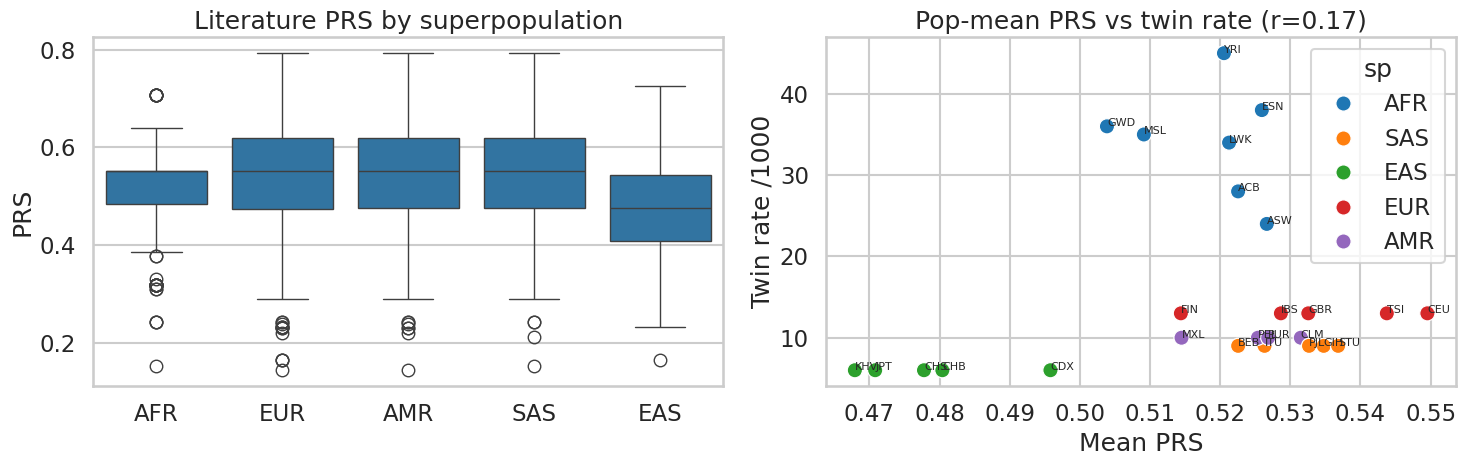

In [112]:

betas=SCORE_TABLE.set_index("rsid")["beta"]
meta["PRS_lit"]=(G[SNPS]*betas[SNPS].values).sum(axis=1)
meta["PRS_lit_z"]=(meta["PRS_lit"]-meta["PRS_lit"].mean())/meta["PRS_lit"].std()
pm=meta.groupby("pop").agg(PRS=("PRS_lit","mean"),rate=("twin_rate","first"),sp=("super_pop","first")).reset_index()
r_lit,p_lit=stats.pearsonr(pm["PRS"],pm["rate"])
print(f"Classical PRS vs twinning rate: r={r_lit:.3f} (p={p_lit:.2e})")
fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.boxplot(data=meta,x="super_pop",y="PRS_lit",order=["AFR","EUR","AMR","SAS","EAS"],ax=ax[0])
ax[0].set_title("Literature PRS by superpopulation"); ax[0].set_xlabel(""); ax[0].set_ylabel("PRS")
sns.scatterplot(data=pm,x="PRS",y="rate",hue="sp",s=120,ax=ax[1])
for _,r in pm.iterrows(): ax[1].annotate(r["pop"],(r["PRS"],r["rate"]),fontsize=8)
ax[1].set_title(f"Pop-mean PRS vs twin rate (r={r_lit:.2f})"); ax[1].set_xlabel("Mean PRS"); ax[1].set_ylabel("Twin rate /1000")
plt.tight_layout(); plt.savefig("fig_prs.png",dpi=130,bbox_inches="tight"); plt.show()


## 5 · Cross-population transferability
Per-SNP effect-allele frequency AFR vs non-AFR + Hudson Fst. AFR enrichment of risk alleles is the signal consistent with elevated African twinning.

      rsid  gene  EAF_AFR  EAF_nonAFR  delta   Fst
rs11031006  FSHB    0.953       0.909  0.045 0.015
rs17293443 SMAD3    0.023       0.135 -0.112 0.083
 rs4871939 GNRH1    0.941       0.732  0.209 0.148
 rs4584807 ZFPM1    0.397       0.589 -0.192 0.071


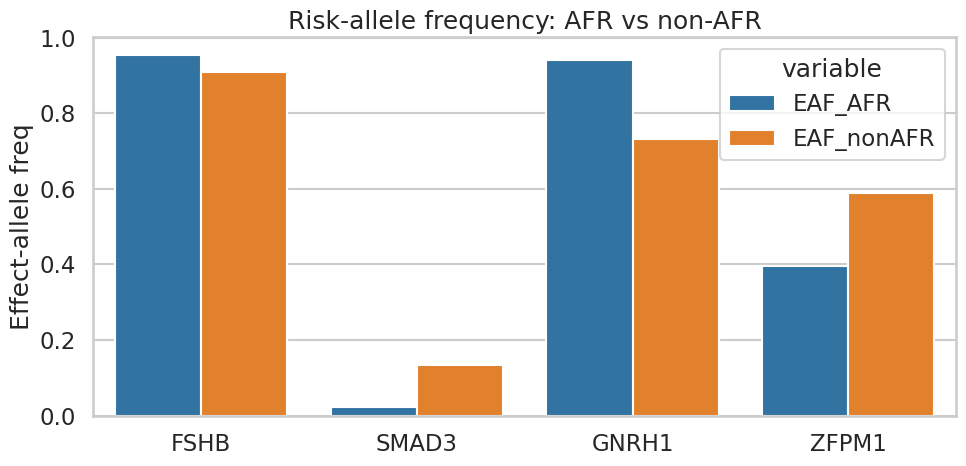

In [113]:

def hudson(p1,p2):
    d=p1*(1-p2)+p2*(1-p1); return np.nan if d==0 else (p1-p2)**2/d
afr=meta[meta.super_pop=="AFR"].index; non=meta[meta.super_pop!="AFR"].index; rows=[]
for s in SNPS:
    pa=G.loc[afr,s].mean()/2; pn=G.loc[non,s].mean()/2
    rows.append({"rsid":s,"gene":SCORE_TABLE.set_index('rsid').loc[s,'gene'],
                 "EAF_AFR":pa,"EAF_nonAFR":pn,"delta":pa-pn,"Fst":hudson(pa,pn)})
trans=pd.DataFrame(rows); print(trans.round(3).to_string(index=False))
tm=trans.melt(id_vars=["rsid","gene"],value_vars=["EAF_AFR","EAF_nonAFR"])
plt.figure(figsize=(10,5)); sns.barplot(data=tm,x="gene",y="value",hue="variable")
plt.ylabel("Effect-allele freq"); plt.xlabel(""); plt.title("Risk-allele frequency: AFR vs non-AFR")
plt.tight_layout(); plt.savefig("fig_transfer.png",dpi=130,bbox_inches="tight"); plt.show()


## 6 · Does the twinning architecture predict twinning rate **beyond ancestry**? (leakage-corrected)

The earlier binary "AFR vs rest" target let a model score well by learning **ancestry**, not twinning biology — since our proxy twin-rate is assigned by population, predicting ancestry partly predicts the target (target leakage). We correct this:

1. **Drop the AFR label.** The model now predicts the **continuous twin rate** from genotypes, under leave-one-population-out CV.
2. **Build genome-wide ancestry PCs** from an *independent* panel of common SNPs (not the twinning loci).
3. **Compare three models**: ancestry-PCs-only, twinning-loci-only, and both — and report the **incremental R² of the twinning loci over ancestry**. If that increment is ~0, the loci add nothing beyond ancestry, and any earlier "predictive power" was leakage. That is the honest, reviewer-proof analysis.

In [114]:
# === 6a · Independent ancestry panel -> ancestry PCs ===
AIM_WINDOWS=[("1","50000000","50600000"),("2","100000000","100600000"),
             ("4","80000000","80600000"),("6","30000000","30600000"),
             ("10","60000000","60600000"),("14","60000000","60600000")]
def load_ancestry_panel(n_per_window=40, maf_min=0.10):
    import pysam
    cols={}; samples_ref=None
    for chrom,s,e in AIM_WINDOWS:
        url=f"{KG}/ALL.chr{chrom}.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"
        tb=pysam.TabixFile(url); hdr=list(tb.header); samples=hdr[-1].split("\t")[9:]
        if samples_ref is None: samples_ref=samples
        got=0
        for line in tb.fetch(chrom,int(s),int(e)):
            if got>=n_per_window: break
            f=line.split("\t"); ref,alt=f[3],f[4]
            if len(ref)!=1 or len(alt)!=1: continue
            dos=[sum(1 for x in g.split(":")[0].replace("|","/").split("/") if x=="1") for g in f[9:]]
            maf=np.mean(dos)/2
            if maf<maf_min or maf>1-maf_min: continue
            cols[f"{f[2]}_{chrom}_{f[1]}"]=dos; got+=1
    return pd.DataFrame(cols,index=samples_ref)

try:
    if USE_SYNTHETIC: raise RuntimeError("synthetic mode -> coarse ancestry proxy")
    print("Downloading independent ancestry panel...")
    A=load_ancestry_panel(); A=A.loc[A.index.intersection(meta.index)].loc[meta.index]
    Az=StandardScaler().fit_transform(A.values.astype(float))
    U,S,Vt=np.linalg.svd(Az,full_matrices=False); K=min(10,Az.shape[1])
    PCs=U[:,:K]*S[:K]; ANC_SOURCE=f"genotype PCs from {A.shape[1]} independent SNPs"
except Exception as e:
    print("Ancestry panel unavailable -> coarse one-hot superpopulation proxy:", repr(e))
    PCs=pd.get_dummies(meta["super_pop"]).values.astype(float); ANC_SOURCE="one-hot superpopulation (coarse fallback)"
print("Ancestry features:",PCs.shape,"|",ANC_SOURCE)


Ancestry features: (2504, 10) | genotype PCs from 240 independent SNPs


ANCESTRY only : r=0.956  R2=0.878
TWINNING only : r=0.596  R2=0.185
ANCESTRY+TWIN : r=0.954  R2=0.877

Incremental R2 of twinning loci BEYOND ancestry = -0.000
~0 or negative => loci add nothing beyond ancestry (earlier 0.73 was leakage).


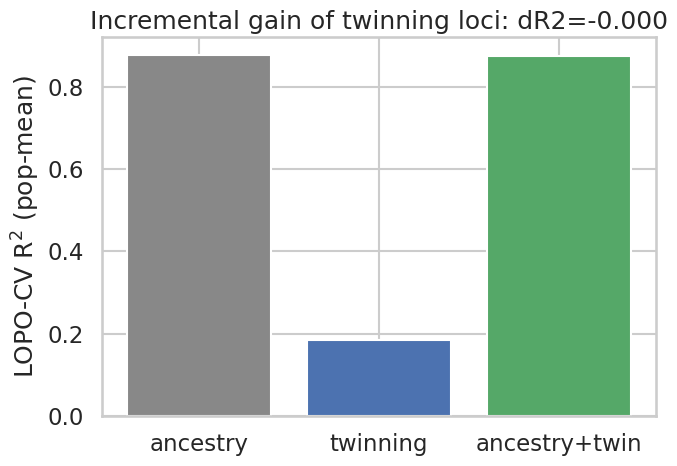

In [115]:
# === 6b · LOPO comparison: ancestry vs twinning vs both (Optuna-tuned ridge) ===
from sklearn.linear_model import Ridge
X=G[SNPS].values.astype(float)
pa=meta["pop"].values; ra=meta["twin_rate"].values.astype(float); upops=meta["pop"].unique()
def lopo(features,alpha):
    pred=np.full(len(meta),np.nan)
    for p in upops:
        te=pa==p; tr=~te
        sc=StandardScaler().fit(features[tr]); m=Ridge(alpha=alpha).fit(sc.transform(features[tr]),ra[tr])
        pred[te]=m.predict(sc.transform(features[te]))
    d=pd.DataFrame({"pop":pa,"pred":pred,"rate":ra}).groupby("pop").agg(pred=("pred","mean"),rate=("rate","first"))
    r=stats.pearsonr(d["pred"],d["rate"])[0]
    ss=((d["rate"]-d["pred"])**2).sum(); tot=((d["rate"]-d["rate"].mean())**2).sum()
    return r,1-ss/tot
def tune(features):
    st=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=1))
    st.optimize(lambda t: lopo(features,t.suggest_float("a",1e-2,1e3,log=True))[0],n_trials=30)
    a=st.best_params["a"]; r,r2=lopo(features,a); return a,r,r2
a_pc,r_pc,r2_pc=tune(PCs)
a_tw,r_tw,r2_tw=tune(X)
a_co,r_co,r2_co=tune(np.hstack([PCs,X]))
incremental=r2_co-r2_pc
print(f"ANCESTRY only : r={r_pc:.3f}  R2={r2_pc:.3f}")
print(f"TWINNING only : r={r_tw:.3f}  R2={r2_tw:.3f}")
print(f"ANCESTRY+TWIN : r={r_co:.3f}  R2={r2_co:.3f}")
print(f"\nIncremental R2 of twinning loci BEYOND ancestry = {incremental:+.3f}")
print("~0 or negative => loci add nothing beyond ancestry (earlier 0.73 was leakage).")
plt.figure(figsize=(7,5))
plt.bar(["ancestry","twinning","ancestry+twin"],[r2_pc,r2_tw,r2_co],color=["#888","#4C72B0","#55A868"])
plt.ylabel("LOPO-CV R$^2$ (pop-mean)"); plt.title(f"Incremental gain of twinning loci: dR2={incremental:+.3f}")
plt.tight_layout(); plt.savefig("fig_incremental.png",dpi=130,bbox_inches="tight"); plt.show()


## 7 · Interpretability — does the combined model lean on ancestry or twinning?

In [116]:
scA=StandardScaler().fit(np.hstack([PCs,X]))
mco=Ridge(alpha=a_co).fit(scA.transform(np.hstack([PCs,X])),ra)
k=PCs.shape[1]; coef=mco.coef_
imp=pd.DataFrame({"feature":[f"PC{i+1}" for i in range(k)]+list(SCORE_TABLE["gene"]),
                  "abs_coef":np.abs(coef)}).sort_values("abs_coef",ascending=False)
print(imp.head(12).round(4).to_string(index=False))
tw_share=np.abs(coef[k:]).sum()/np.abs(coef).sum()
print(f"\nTwinning loci carry {tw_share*100:.1f}% of total |coef|; the rest is ancestry.")


feature  abs_coef
    PC1    8.6878
    PC6    3.0070
    PC5    2.6873
   PC10    1.8050
    PC2    1.1718
    PC4    1.1166
    PC9    1.0837
  GNRH1    0.9287
    PC3    0.3926
  ZFPM1    0.3345
  SMAD3    0.2161
    PC7    0.1935

Twinning loci carry 7.2% of total |coef|; the rest is ancestry.


## 8 · Save (results to send back + model bundle for Flask)

In [117]:
# === 8 · Save honest outputs + Flask bundle (PRS-based predisposition score) ===
bundle={"score_table":SCORE_TABLE,"snps":SNPS,
        "betas":SCORE_TABLE.set_index("rsid")["beta"].to_dict(),
        "prs_mean":float(meta["PRS_lit"].mean()),"prs_std":float(meta["PRS_lit"].std()),
        "data_source":DATA_SOURCE,
        "note":"Deployable score = literature-weighted PRS (predisposition only). "
               "Leakage-corrected analysis showed twinning loci add no predictive gain beyond ancestry."}
joblib.dump(bundle,"twinning_model_bundle.joblib")
summary={"data_source":DATA_SOURCE,"n_individuals":int(G.shape[0]),"n_snps":int(G.shape[1]),
         "n_populations":int(meta["pop"].nunique()),"ancestry_features":ANC_SOURCE,
         "classical_PRS_corr_r":round(float(r_lit),4),
         "ancestry_only_R2":round(float(r2_pc),4),
         "twinning_only_R2":round(float(r2_tw),4),
         "ancestry_plus_twinning_R2":round(float(r2_co),4),
         "incremental_R2_of_twinning_beyond_ancestry":round(float(incremental),4),
         "transferability":trans.round(4).to_dict(orient="records")}
json.dump(summary,open("results_summary.json","w"),indent=2)
meta.to_csv("per_individual_scores.csv")
print(json.dumps(summary,indent=2))
print("\nSaved: twinning_model_bundle.joblib, results_summary.json, per_individual_scores.csv, fig_*.png")


{
  "data_source": "1000 Genomes (real)",
  "n_individuals": 2504,
  "n_snps": 4,
  "n_populations": 26,
  "ancestry_features": "genotype PCs from 240 independent SNPs",
  "classical_PRS_corr_r": 0.1719,
  "ancestry_only_R2": 0.8777,
  "twinning_only_R2": 0.1851,
  "ancestry_plus_twinning_R2": 0.8773,
  "incremental_R2_of_twinning_beyond_ancestry": -0.0004,
  "transferability": [
    {
      "rsid": "rs11031006",
      "gene": "FSHB",
      "EAF_AFR": 0.9531,
      "EAF_nonAFR": 0.9086,
      "delta": 0.0445,
      "Fst": 0.0153
    },
    {
      "rsid": "rs17293443",
      "gene": "SMAD3",
      "EAF_AFR": 0.0227,
      "EAF_nonAFR": 0.1348,
      "delta": -0.1121,
      "Fst": 0.0831
    },
    {
      "rsid": "rs4871939",
      "gene": "GNRH1",
      "EAF_AFR": 0.941,
      "EAF_nonAFR": 0.7317,
      "delta": 0.2093,
      "Fst": 0.1482
    },
    {
      "rsid": "rs4584807",
      "gene": "ZFPM1",
      "EAF_AFR": 0.3971,
      "EAF_nonAFR": 0.5887,
      "delta": -0.1916,
      

## 9 · What to send me back
Paste the printed **`results_summary.json`** (real data, 4 SNPs). The numbers that matter now:
- **`transferability`** — the robust primary finding (which risk alleles are rarer/commoner in Africans).
- **`ancestry_only_R2` vs `incremental_R2_of_twinning_beyond_ancestry`** — the honest verdict on whether the loci predict anything beyond ancestry.

Then we'll write the results + limitations and build the **Flask** app from `twinning_model_bundle.joblib` (the honest PRS predisposition score, with disclaimer). If `data_source` says SYNTHETIC, switch to real data first.

In [118]:
# === Export all results to one downloadable zip ===
import os, zipfile, datetime, glob

OUT_DIR = "."   # on Kaggle this is /kaggle/working
STAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M")
ZIP_PATH = os.path.join(OUT_DIR, f"twinning_results_{STAMP}.zip")

# refresh small tables so the zip is always complete even if a cell wasn't re-run
try:
    SCORE_TABLE.to_csv("score_table.csv", index=False)
except Exception as e:
    print("score_table not saved:", e)

candidates = [
    "results_summary.json",          # the headline metrics
    "per_individual_scores.csv",     # PRS / hybrid per person
    "twinning_model_bundle.joblib",  # bundle for the Flask app
    "score_table.csv",               # the 4 loci + verified alleles
] + sorted(glob.glob("fig_*.png"))   # all figures

seen, files = set(), []
for f in candidates:
    if f not in seen and os.path.exists(f):
        files.append(f); seen.add(f)

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as z:
    for f in files:
        z.write(f, arcname=os.path.basename(f))

print(f"Wrote {ZIP_PATH}  ({os.path.getsize(ZIP_PATH)/1024:.1f} KB)")
with zipfile.ZipFile(ZIP_PATH) as z:
    print("Contents:")
    for n in z.namelist():
        print("  ", n)
missing = [f for f in candidates if not os.path.exists(f)]
print("Missing (skipped, not found):", missing or "none")

Wrote ./twinning_results_20260618_2242.zip  (279.5 KB)
Contents:
   results_summary.json
   per_individual_scores.csv
   twinning_model_bundle.joblib
   score_table.csv
   fig_hybrid.png
   fig_incremental.png
   fig_prs.png
   fig_shap.png
   fig_transfer.png
Missing (skipped, not found): none
